# ML pipeline experiemnt with Random Roest ML (RF) using SciKit SW Toolkit
Class: CSC 659/859

Semester: Spring 2026

Date: March 14, 2026

Name: Veronica Yuen

Email: vkyuen@sfsu.edu <div style="page-break-after: always;"></div>


# Audit of Original database
Done following the checklist provided after loading the data. 
| Question                                                           | Answer                                                                                                                                                                                         |
| ------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. Description of features and data formats are well documented    | There are 871 entries, each which have 609-1  = 608 features, the last column is the label                                                                                                     |
| 2. How are class labels obtained/verified wrt. ground truth        | Ground truth is established by independent biological research as specified by the paper: "Cell type discovery using single-cell transcriptomics: implications for ontological representation" |
| 3. Is demography well covered in adequate and fair way             | A standard reference nomenclaure was used to keep things consistant.  The data is gathered from a human brain, no dientification information was included, so there is no identifable bias.    |
| 4. Check number of samples in each decision class                  | 0: 781<br>1: 90                                                                                                                                                                                |
| 5. Type of each feature                                            | The features are all numbers, the labels are cagetorical, but that column will not be included with the training.                                                                              |
| 6. Are there missing values and do they need to be imputed and how | There are no missing values in this data set                                                                                                                                                   |
| 7. Are there enough samples compared to number of features used    | Yes, because of the randomness of Random Forest. Traditionally there needs to be more samples, but based on the best practices of the number of features to consider, there are enough samples |
| 8. Check privacy issues                                            | There is no identifiable information so there shouldn't be any privacy issues                                                                                                                  |

**Table 1: Original database audit** Training data base audit checklist as provided. Some of the values are provided after analyxing the data in the .csv file, and other based on the paper that as provided that is acting as the ground truth.

# Creation of training DB and verification DB
After loading the data, two lists of indices for the labels was generated. An index from both lists were selected and placed into a validation_data set.  The training set is created using the imported data set, excluding the two indices that were selected for the validation set. 

To check that it was done correctly, the labels of the loaded data, training data, and validation data were compared. Comparing the values per label, they match with the values from the original data set, just one short in both classes. Looking at the remaining values after taking out two samples for the validation set.

| Training 0 | Training 1 |
| :--------: | :--------: |
| 780        | 89         |

**Table 2: Training data split breakdown** Looking at the number of the two labels for the training dataset that created by copying the original dataset, excluding the two samples that were held back for the validation set.

The validation set was created by taking the 13th and 413th value from the original data set.  There are only two values in the set, as seen in the table below. 

| Validation 0 | Validation 1 |
| :----------: | :----------: |
| 1            | 1            |

**Table 3: Validation data split breakdown** Shows that there is a sample of each label in the validation set. 

Once the training and validation sets are created, the label of both sets were extracted and saved seperatly to match the x,y notation of features and target that is used by scikit-learn. 

# SW tools
For this project, A Jupyter Notebook was created in Visual Studio Code.  As for the pipeline, conada (26.1.1) for the package manager with the following packages: scikit-learn (1.8.0), numpy (2.4.2). pandas (3.0.1)

# Experimental Methods and Setup

## Describe Method 1: Basic training with Out of bag accuracy estimate
Out-of-Bag (OOB) accuracy is used to estimate how the model will do on future data that has not been seen.  Because of the property of random forest, seperate cross validation is not needed.  It is based on bootstrap aggregrating technique that is used to train the forest.  

The data each tree is trained on is a bootstrap version of the training data.  The bootstrapped set is created by random sampling, with about 36.8% of the original data is omitted (which are the out-of-bag samples for the tree). For every sample in the dataset, the model will identify the subset of trees that have not seen the sample.  Those trees are presented with the new data and asked to vote for the correct label. Once the subset of trees have voted, the final prediction is the label that had the majority vote from the trees.  To calculate the error, the model compare the votes to the final decision. The final OOB error rate is calculated by repeting the process above for all the samples, and averaging all the error values. 

Scikit-learn's random forest model will be used to train the model and run the experiment.  

Using grid search to find the best hyper-parameters for random forest training.  Because Sci-learned is used, there is no way to change the cutoff range for the voting.  In the table below, it shows the two NTREE and three MTRY values that will be tried in the grid search.  Since there are 608 features, the square root of 608 is 24.65765.  For the hyper-parameters, integers are needed, so it will be rounded to 25. Going with the recommended values from best practices, the rounded calculated values in the table. While it would be nice to test out different numbers for the cutoff range, scikit-learn has that value set to 0.5, so no changes can be made to it.
| Hyper-parameter      | Value                                                        |
| -------------------- | ------------------------------------------------------------ |
| ntree (n_estimators) | 500, 750, 1000                                               |
| mtry (max_features)  | 0.5 x SQRT(608) = 12<br>SQRT(608) = 25<br>2 x SQRT(608) = 50 |
| cutoff range         | 0.5                                                          |

**Table 4: Hyper-parameter values for OOB trials** This shows the values for the hyper-parameters that will be used in grid search to identify the combination that will create the best random forest model. 

After setting up the values, and being sure that oob_score is set to true, start running the different trials, and see which combination gives the Out of Bag (OOB) score. The score attribute is a true accuracy estimate of future performance of the model. For this setup, that is the main accuracy measure. Can use values from the confusion matrix to calculate the different metrics. 

| Metric    | Formula                          |
| --------- | -------------------------------- |
| Accuracy  | (TP + TN) / (TP + TN. + FP + FN) |
| Precision | TP / (TP + FP)                   |
| Recall    | TP / (TP + FN)                   |
| F1-Score  | 2 TP / (2 TP + FP + FN)          |
| OOB Error | 1 - OOB accuracy                 |

**Table 5: Metrics formulas** The 4 main metrics that can be calculated using the values from the confusion matrix.

As a reminder, scikit-learn returns confusion matrix in a different layout than most. 
|                | 0 (predicted) | 1 (predicted) |
| -------------- | :-----------: | :-----------: |
| **0 (actual)** | tn            | fp            |
| **1 (actual)** | fn            | tp            |

**Table 6: Scikit-learn confusion matrix** A reminder of the standard confusion matrix generated by scikit-learn for binary classes. 

Scikit-learn's random forest will be used for the model, as well as the confusion matrix class to get the numbers needed for later calculation. 

## Describe Method 2: Using 3 fold cross validation
To go though the process to do 3-fold cross validation, the first step is to sperate the training data into 3 folds.  Idealy going to try to do a startified partion so that each fold has the same portion of labels as the original dataset. This method gives full accuracy estimates of the performance. 

Using the train_test_split, the training data can be split into 3. The first split will split the 869 samples with test size = .33. Then the remaining data can be split into half, give three groups with 289 or 290 (2 groups) elements. 

Once that has been done, for each combination of the three folds, two folds will be used to train, the final fold for testing.  After training, use the model to predict and score the testing data to get the accuaracy for that fold.  Once that has been done for all the combination, combine the confusion matrix (add corresponding quadrants from each fold's confusion matrix).  Using the combined confusion matrix, the accuracy will be calculated based on the combined confusion matris. With the information from the confusion matrix, the same metrics from Table 5 can be used to see how well the model is doing.

For the models, the hyper parameters used will be the set with the lowest errror from method one.  In the results table, there were two combindations that gave the lowest error rate. For effeciency, a combination of NTREE = 500 and MTRY of 50 can be used, but this experiment will use the other combination, where NTREE = 500 and MTRY= 50. 

While scikit-learn has a method that can be called for cross validation, it is good to know how the process works.  As an aside, it would be a good sanity check and test to compare the more manual cross validation to the one-line version. 

| Hyper-parameter      | Value              |
| -------------------- | ------------------ |
| ntree (n_estimators) | 1000               |
| mtry (max_features)  | 2 x SQRT(608) = 50 |
| cutoff range         | 0.5                |

**Table 7: Hyper-parameter values for cross validation** A list of the hyper-parameter values that will be used for the 3-fold validation random forest model. 

For each fold, a confusion matrix will be generated so the classification matrix values can be calculated (see Table 5 for the formula).  The data from all three confusion matrices will be combined and used to calculate the average metric for the cross validation.  Scikit-learn's random forest model will be used. Also need the stratifiedKFold methods to help split the data into 3. 

## Describe verification and comparison of results from methods 1 and 2
In order to be able to compare the two methods fairly, the settings with the lowest error rate was selected from method 1, and used to set up the models for method 2.  With the setting the same, the classification evaluation metrics can be calculated and compared.  

For both methods, a final confusion matrix will be generated and compared to each other.  While more confusion matrices are created by both methods, it would be a better comparison to look at the final, average matrix.  

With the same data, and similar data, the classification evaluation metrics are expected to be similar. Thus acting as a verification of each other. 

# Actual Results of RF Training and Accuracy Estimates
Looking at the results of the the methods described above. 
## OOB accuracy estimate
For the decided values, a classifier was created with the right parameters, and the results analized. Manually doing grid search to find the best combination of hyper-parameter for the best results.  Below are some code snippits for the first model. 
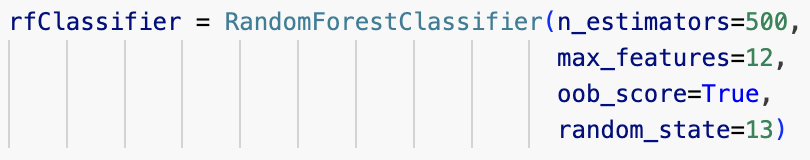

**Image 1: Code for creating a random forest classifier** For this section, the n_estimators and max_features values will be changed to get different OOB values and confusion matrices. 

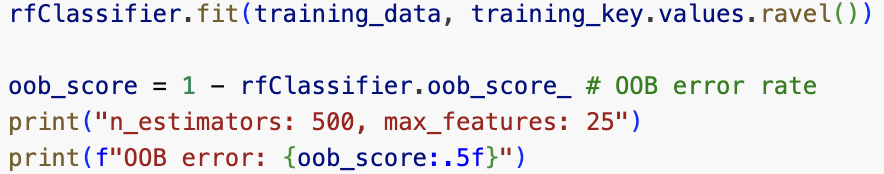

**Image 2: Code for fitting the model to the training data and generating the OOB score** The model is trained using the fit method in one line. In order to get the OOB error rate, the value provided by Scikit-learn has to be taken out of 1.  The value calculated is actually the OOB accuracy, so in order to get the error score, 1 - accuracy, as mentioned in Table 5.  Results are reported to 5 decimal places as reqested.  Using fewer decimal places will make the score the same, see Table 7 for an example of why this many decimal places is needed.

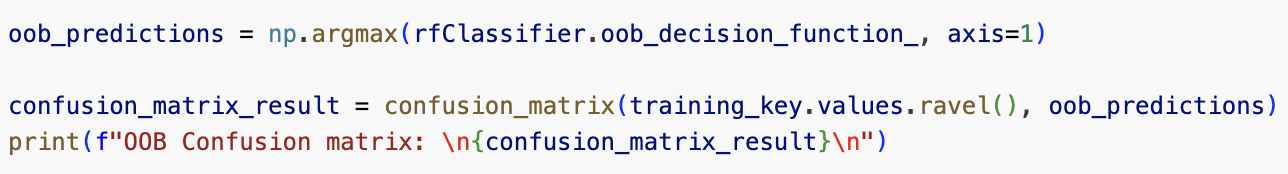

**Image 3: Code for generating the confusion matrix** OOB predictions are needed to compare to the actual labels, so that the confusion matrix can be generated. 

### OOB results
Three values of NTREE and MTRY were used to generate OOB error. See calculation in Table 5 and the code snippet in image 2. 
|         | 500     | 750     | 1000    |
| ------- | ------- | ------- | ------- |
| **12**  | 0.01956 | 0.01956 | 0.02071 |
| **25**  | 0.01611 | 0.01496 | 0.01496 |
| **50**  | **0.01381** | 0.01496 | **0.01381** |

**Table 7: OOB scores** The top header corresponds to the ntree values used, the column to the right are the different values of mtry that were used. The lowest OOB score, 0.01381 have been bolded in the table. 

The confusion matrices are grouped by the number of ntree values. 
| feature = 12   | 0 (predicted) | 1 (predicted) | feature = 25   | 0 (predicted) | 1 (predicted) | feature = 50   | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- | -------------- | ------------- | ------------- | -------------- | ------------- | ------------- |
| **0 (actual)** | 780           | 0             | **0 (actual)** | 779           | 1             | **0 (actual)** | 780           | 0             |
| **1 (actual)** | 17            | 72            | **1 (actual)** | 13            | 76            | **1 (actual)** | 12            | 77            |

**Table 8: OOB Confusion matrix for OOB error where ntree = 500** The upper left cell shows the number of mtrys (features) used for the confusion matrix. 

| feature = 12   | 0 (predicted) | 1 (predicted) | feature = 25   | 0 (predicted) | 1 (predicted) | feature = 50   | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- | -------------- | ------------- | ------------- | -------------- | ------------- | ------------- |
| **0 (actual)** | 780           | 0             | **0 (actual)** | 780           | 0             | **0 (actual)** | 780           | 0             |
| **1 (actual)** | 17            | 72            | **1 (actual)** | 13            | 76            | **1 (actual)** | 13            | 76            |

**Table 9: OOB Confusion matrix for OOB error where ntree = 750** The upper left cell shows the number of mtrys (features) used for the confusion matrix. 

| feature = 12   | 0 (predicted) | 1 (predicted) | feature = 25   | 0 (predicted) | 1 (predicted) | feature = 50   | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- | -------------- | ------------- | ------------- | -------------- | ------------- | ------------- |
| **0 (actual)** | 780           | 0             | **0 (actual)** | 780           | 0             | **0 (actual)** | 780           | 0             |
| **1 (actual)** | 13            | 76            | **1 (actual)** | 13            | 76            | **1 (actual)** | 12            | 77            |

**Table 10: OOB Confusion matrix for OOB error where ntree = 1000** The upper left cell shows the number of mtrys (features) used for the confusion matrix. 

Using the combination that gave the lowest OOP error, where ntree = 1000 and mtry = 50. The classification metrics were calculated using the confusion matrix information associated with the trial. 

| feature = 50   | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- |
| **0 (actual)** | 780           | 0             |
| **1 (actual)** | 12            | 77            |

**Table 11: Confusion matrix** Pulled out the confusion matrix for the combination that gave the lowest OOB error. 

| Metric    | Formula                          | Value   |
| --------- | -------------------------------- | ------- |
| Accuracy  | (77 + 780) / (77 + 780 + 0 + 12) | 0.98619 |
| Precision | 77 / (77 + 0)                    | 1.00000 |
| Recall    | 77 / (77 + 12)                   | 0.86517 |
| F1-Score  | 2 x 77 / (2 x 77 + FP + 12)      | 0.92771 |

**Table 12: Classification metrics for lowest OOB error** Metrics calculated using the confusion matrix values. 

## 3-fold cross validation results
The first step is to break the training data into three equal parts.  The following snippt of code was generated by Gemini.  

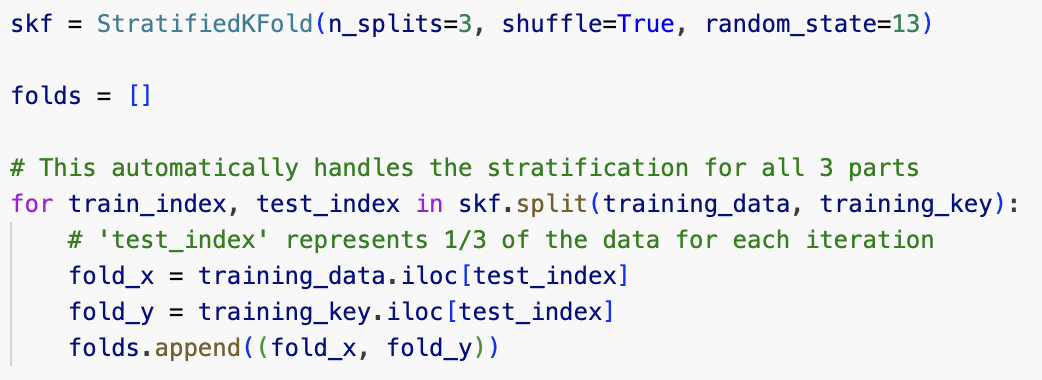
**Image 4: Code for stratified partitioning the training data** Using Scikit-learn's stratifiedKfold, the data was shuffled and split.  The same random state was used for reproduciability. 


Focusing on the first fold, where the first group is the test data, while groups 2 and 3 are used as the training data. 

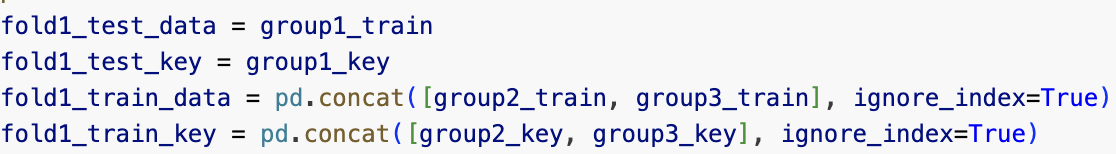
**Image 5: Code for setting the training and test sets for fold 1** Most of the prep is for the training set, where groups 2 and 3 are concatnated together to form on dataframe.


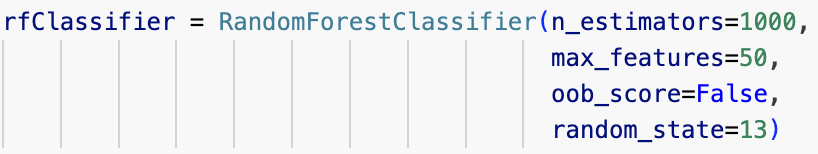
**Image 6: Code for setting up random forest** The parameters used for the cross validation models. The values are chosen from the best performing values from the first method.  While oob_score did not have to be included (default value is False), it is nice to be explicit.


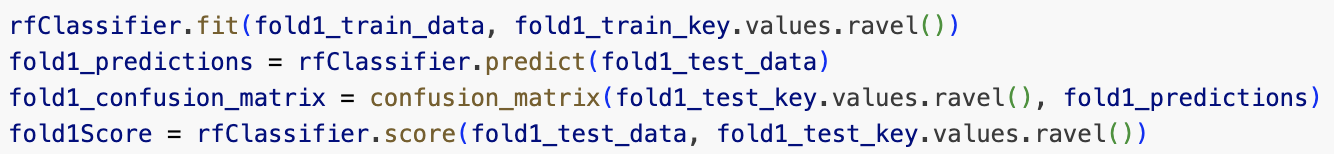
**Image 7: Code for training and generating the confusion matrix** The models are trained on the data, and tested to create the confusion matrix for analysis.

### 3-fold groups
Looking at the data, below is the breakdown of how the data was split. 

|                      | group 1 | group 2 | group 3 |
| -------------------- | ------- | ------- | ------- |
| **number of values** | 290     | 290     | 289     |
| ** Label 0**         | 260     | 260     | 260     |
| **Label 1**          | 30      | 29      | 29      |

**Table 13: Breakdown of split** Shows how many samples of class 1 and class 0 are in the different splits (called groups).



| Fold number | train combination | train 0         | train 1      | test combination | test 0 | test 1 |
| ----------- | ----------------- | --------------- | ------------ | ---------------- | ------ | ------ |
| 1           | group 2 + group 3 | 260 + 260 = 520 | 30 + 29 = 59 | group 1          | 260    | 30     |
| 2           | group 1 + group 3 | 260 + 260 = 520 | 30 + 29 = 59 | group 2          | 260    | 30     |
| 3           | group 1 + group 2 | 260 + 260 = 520 | 30 + 30 = 60 | group 3          | 260    | 29     |

**Table 14: Label count for each fold** Based on the split, a breakdown of the labeled training and test data for each fold that was done. 


| Fold 1         | 0 (predicted) | 1 (predicted) | Fold 2         | 0 (predicted) | 1 (predicted) | Fold 3         | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- | -------------- | ------------- | ------------- | -------------- | ------------- | ------------- |
| **0 (actual)** | 260           | 0             | **0 (actual)** | 259           | 1             | **0 (actual)** | 260           | 0             |
| **1 (actual)** | 8             | 22            | **1 (actual)** | 3             | 27            | **1 (actual)** | 4             | 25            |

**Table 15: Confusion matrix for each fold** The confusion matrix that is generated after each fold. The fold reference is at the top left cell of the table. 

| Fold | mean accuracy |
| ---- | ------------- |
| 1    | 0.97241       |
| 2    | 0.98621       |
| 3    | 0.98616       |

**Table 16: Mean accuracy per fold** In addition to the confusion matrix, the score of the classifer was generate, which is the same as the average accuracy for the fold. 

|                | 0 (predicted)         | 1 (predicted)     |
| -------------- | --------------------- | ----------------- |
| **0 (actual)** | 260 + 259 + 260 = 779 | 0 + 1 + 0 = 1     |
| **1 (actual)** | 8 + 3 + 4  = 15       | 22 + 27 + 25 = 74 |

**Table 17: 3-fold combined confusion matrix** Taking the values from the individual confusion matrices one confusion matrix is created. 

| Metric    | Fold 1  | Fold 2  | Fold 3  | Average |
| --------- | ------- | ------- | ------- | ------- |
| Accuracy  | 0.97241 | 0.98621 | 0.98616 | 0.98159 |
| Precision | 1.00000 | 0.96429 | 1.00000 | 0.98667 |
| Recall    | 0.73333 | 0.90000 | 0.86207 | 0.83146 |
| F1-Score  | 0.84615 | 0.93103 | 0.92593 | 0.90244 |

**Table 18: Classification metrics for all folds** The formula from Table 5 along with each confusion matrix was used to calculate the measures. For the average column, the valuse from the combined confusion matrix was used. 

## Comparision of the two methods
Both methods were stright forward to program with all the help that was given.  Looking at the different metrics, they give similar values for all the metrics that were calculated.  Out of curicuriosity, an additional column for the standard deviation between the two values was included to see similar the metrics are.  With some rounding, the numbers are very similar.  

With such similar values, the two methods can be used to verify each other.  

| Metric    | OOP     | 3-Fold Verification | Standard deviation |
| --------- | ------- | ------------------- | ------------------ |
| Accuracy  | 0.98619 | 0.98159             | 0.00325            |
| Precision | 1.00000 | 0.98667             | 0.00943            |
| Recall    | 0.86517 | 0.83146             | 0.02384            |
| F1-Score  | 0.92771 | 0.90244             | 0.01787            |

**Table 19: Combination classification metrics table** Using values from Table 12 and 18, the values for the different metrics is placed together. An additioinal column for standard deviation is used to highlight how similar the results for the two methods are. 

The ROC curves generated by the two methods did very well and are very similar. 
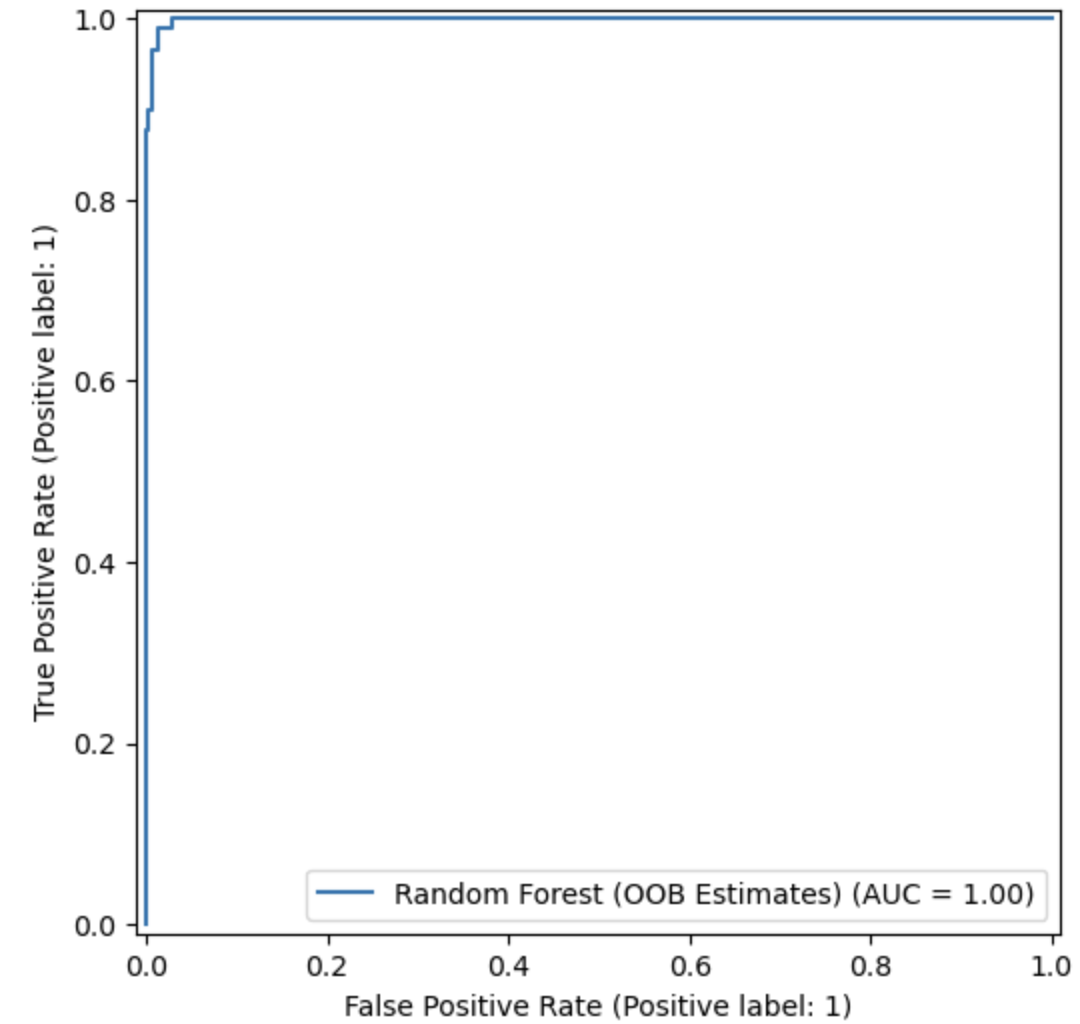
**Image 8: ROC Curve from OOB Prediction** Using the OOB predictions to plot out a ROC Curve. 
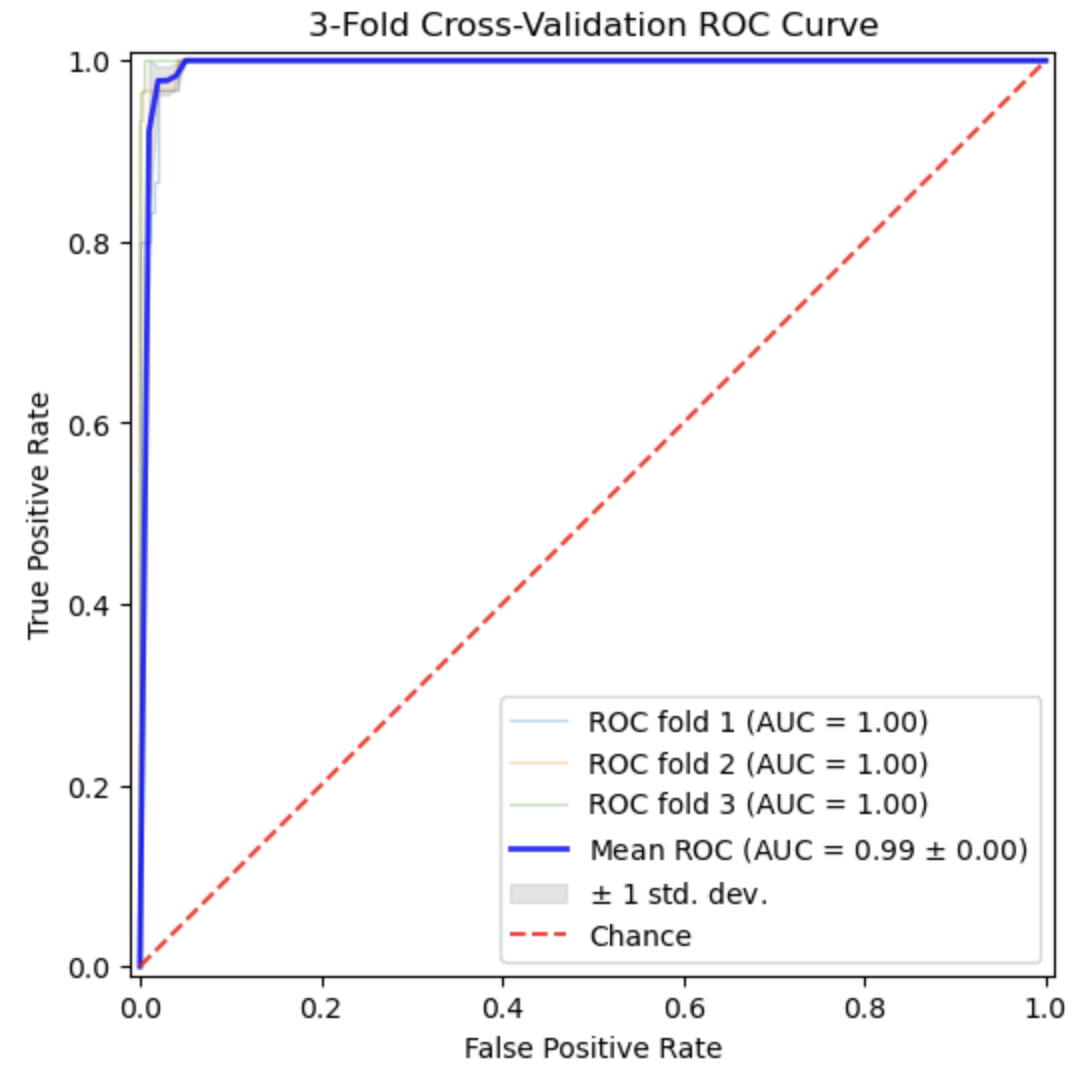
**Image 9: ROC Curve using data from 3-fold valudation** Using 3-fold verification predictions to plot out ROC Curve. 

# Feature Ranking
Using the best trained model, which is the version using NTREE = 1000, and MTRY = 50. Following the hints and Gemini's snippets, Gini was used to help score the importance of the features, then graphed into bar charts, showing the top 10 features. 
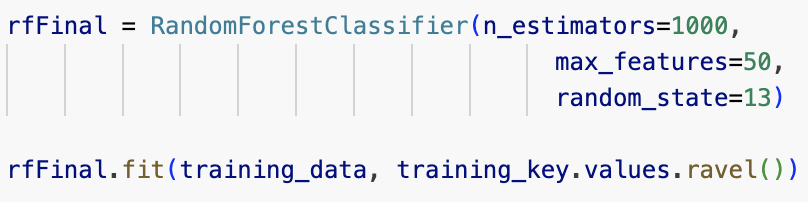

**Image 10: Code for creating another copy of the best model** Using the random forest model where NTREE = 1000, and MTRY = 50

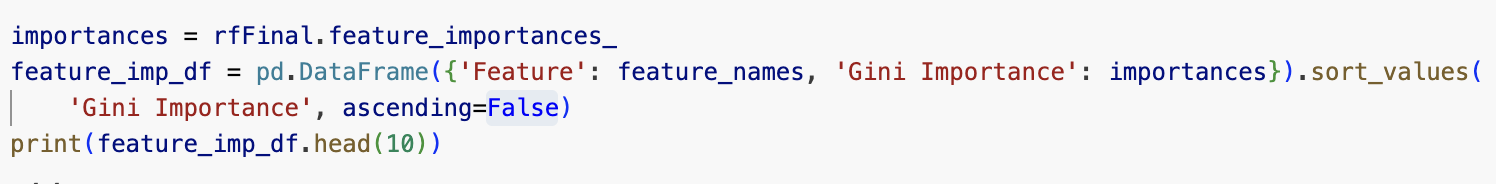
**Image 11: Code for getting the Gini score** Using the Gini scores to rank the important features and taking a look at the top 10 results


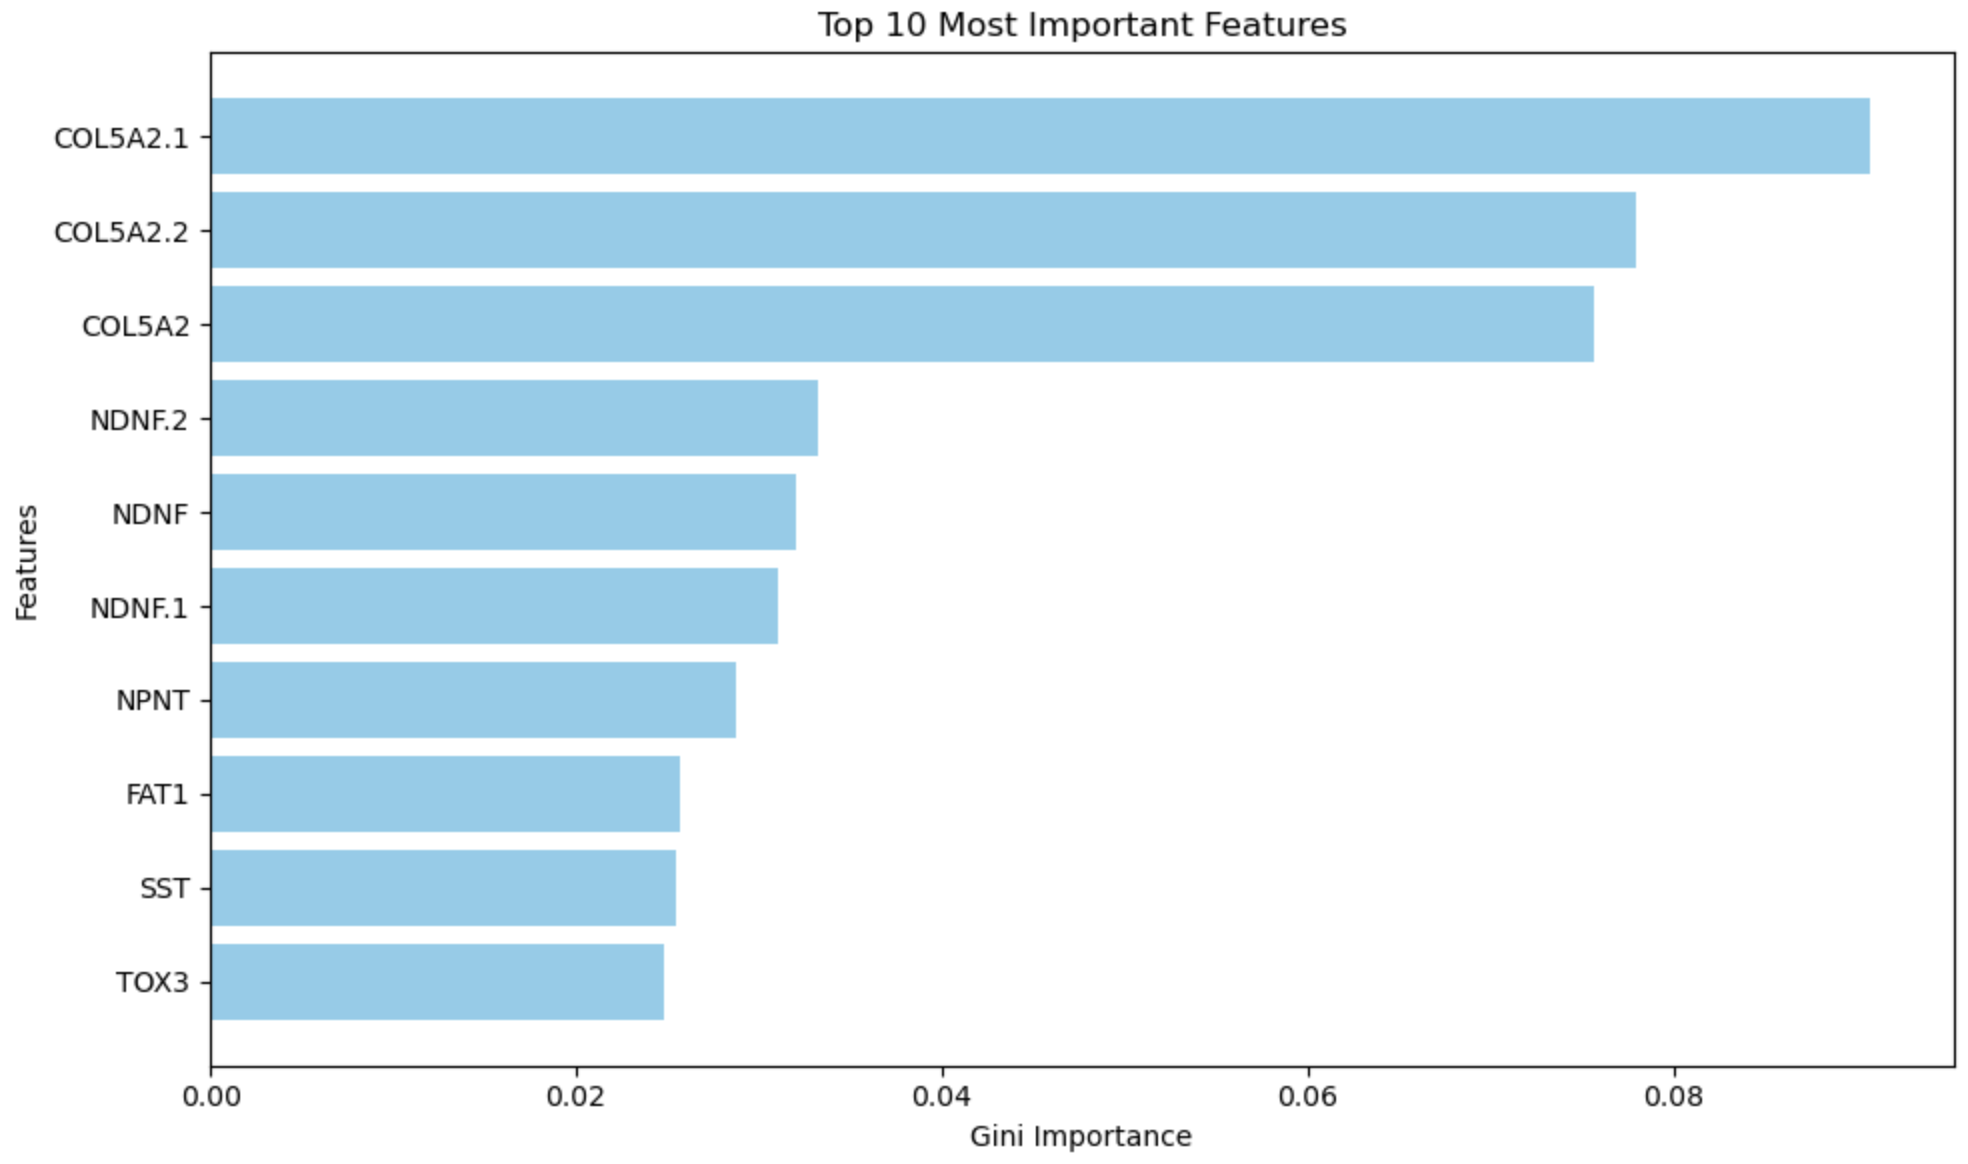
**Image 12: Code for Gini ranking of top 10 most important features** Using the fitted Random forest, the most important features were extraploated from the model, using the Gini score to rank how important the features are. 

Ranking the values show, as expected from the paper, that the COL5A2, NDF, and FAT1 expression is a very good indication of an i1 cluster.  Of the 10 features printed, 3 are COL5A2, 3 are NDNF, and 1 is FAT1.  So 7 of the 10 features are known to be expressed by the cluster.  And they also account for the top-6 of the features.  Looking at them as family, then there is heavy correlation with the top 2. 

To be used in production, it will be interesting to see if the top 6 can be used as the focus for identification of the il cluster.  That correlates wtih the top two families of expressed genes in the score.  But that might be too big of a cut off, especially if the COL5A2 gene is expressed in other clusters.  It could be used to help narrow things down.  But assuming the presence COL5A2 and NDNF family of genes is enough to identify the cluster, that should be enought to identify a good majority of the clusters. 

# RF Run Time test
The model used is the same as the one used feature ranking, see Image 10. Doing a run time test, was done using the .predict method, see Image 13 below. 

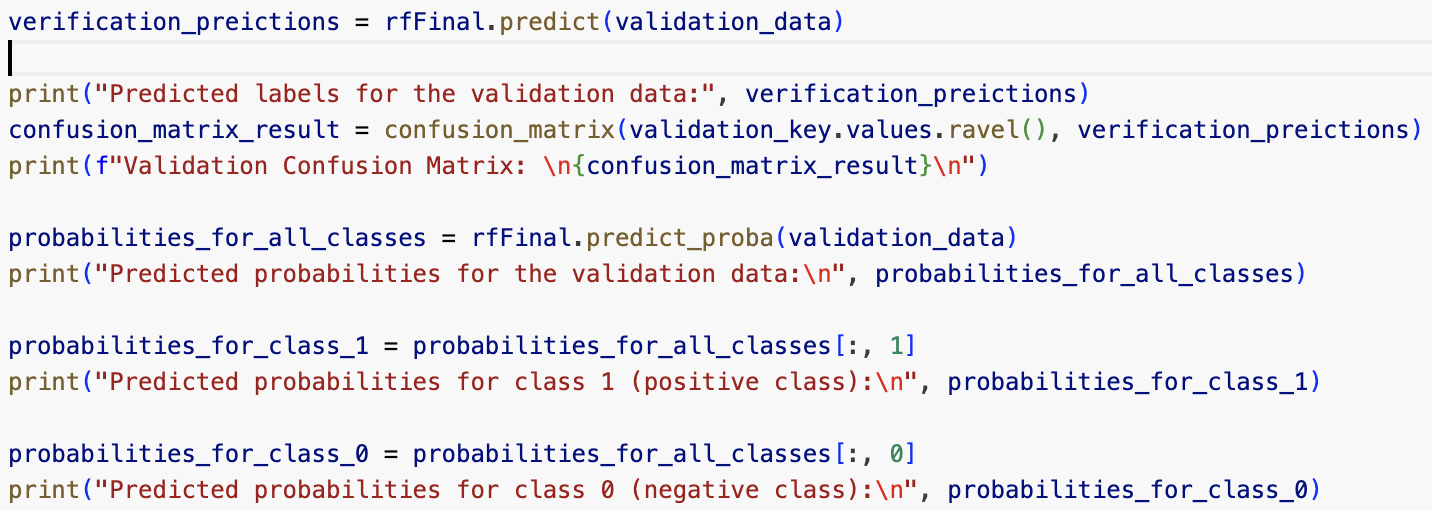
**Image 13: Code for predicting on the validation set and getting the different probabilities and stastics** Using the final model, the .predict method was used to run the prediction on the validation data. The latter commands are for generating the confusion matrix, as well as the predictd probability for the validation set. 

## Classification results
|                | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- |
| **0 (actual)** | 1             | 0             |
| **1 (actual)** | 0             | 1             |

**Table 20: Confusion matrix for the prediction done on the validation set** Looking at the confusion matrix, there are only values on the main diagnal that cooresponds to the true positive and true negative, showing the model make the right prediction.

|                | 0 (predicted) | 1 (predicted) |
| -------------- | ------------- | ------------- |
| **0 (actual)** | 0.99400       | 0.00600       |
| **1 (actual)** | 0.26200       | 0.73800       |

**Table 21: Probability matrix for the prediction** Show the probability or confidence of the model when it made the prediction

## Discussion
The verification samples were correctly classified by the model. Looking at the probability matrix that was generated by the model, gives an average correct probability of 86.6% which is pretty high.  And the fact that the probability for falst positives and negatives are low is very reassuring. I have confidence with this given classification. 

It is interesting to take methods that are provided, and break them up into seperate steps.  This process makes it easier to understand what different methods will do, and how things are calculated.  While it is easy to just follow the one line method to get things done, it is important to have an idea of what is going on. 

With this project, there are areas that can be changed and improved.  For example, with the OOB, methods can be used to change the hyper-parameters. It will be interesting to set up grid search, and try more values for NTREE and MTRY, to be able to plot how they affect the final prediction.  

# Resources
Geek for geeks:
- [random forest article](https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/)
- [OOB errors for random forests in scikit learn](https://www.geeksforgeeks.org/machine-learning/oob-errors-for-random-forests-in-scikit-learn/)
- [random forest hyperparameter turning in Python](https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/)
- [Feature Importance with Random Forests](https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/)

Scikit-learn:
- [ROC Curve](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_roc_curve_visualization_api.html#sphx-glr-auto-examples-miscellaneous-plot-roc-curve-visualization-api-py)

Dragutin Petkovic for providing the data, report base, hints, code snippets

# Appendix I (GenAI Use)

## Google search AI Overview (Gemini 3)
- A lot of Google searches were used to get information about environemnt set up, such as which libraries needed to be installed for the project to run and be exported correctly. A lot of times, it provided code snippets, such as conda install jupyter. 
- Ranking: 4 
- The tool is very helpful, especially when it came to figuring out some of the error messages and how to get around it. Though sometimes it takes a little time to go through the different system options and variables before getting to an option that works for the setup. 
### Major prompts
- How to...
- pandas get index where value equals 
- look up how to correct certain errors
- I am trying to calculate a confusion matrix for the prediction, but all the values are correct. Pasted code snippet
- Given a dataset in scikit-learn, how do to do a stratified 3-fold partition?
- For random forest with OOb, can you do roc curve
- After 3 fold verification how to plot a roc curve
- Given top 10 Gini score how to plot it in a bar graph in matlibplot
- how can i get the plot so the higher numbers are on the top?
- Is it possible to make a prediction and get the probability for all the classes out to 5 decimal places?
## NotebookLM (Gemini 3)
- This tool helped as a sanity check with the inforaiton about the reference paper, as well as generating a sample skeleton report based on the requirements of the assignment. 
- Ranking: 4.5
### Major prompts
- Based on ruberic, can you generate a skeleton report for me?
- Can you tell me more about this paper?
- Can you tell me more about the dataset?
- Can you check my explination of the concept against the sources and tell me if anything needs to be changed?
- What is a good way to compare the OOB and cross validation results?
- Will the following code split the data into 3 parts?
## GitHub Copilot
- AI assistant for coding in Visual studio code. While no specific prompt is used, there are often tips and highlights when there are suggestions of what can be improved.  It is convenient that it is integrated with the ide.  
- Ranking: 4
### Major prompts
- No specific prompts were used, though suggestions were used to get the syntax and next step
- For example, when splitting the data, and saving it as a .csv file, typing the command out for the training data, the auto-complete offered to do the same with the validation data, using the filename matching the first naming convention. 
- Some of the suggestions include bits of code that are needed. With some of the added auto-complete option, it helps show what was missed in a way that makes it easy to look up why something needs to be included. 


# Appendix II (code)

In [94]:
# Keeping all the import statements in one cell for better organization and readability.
import pandas as pd
import os

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc

## Data Audit
Starting to load and set up the training and validation set.  The data is loaded into a dataframe, two samples are removed for the validation set. With the file setup, there is a data folder that will store the original .csv file as well as any .csv file that will be generated. 

In [2]:
# Purpose: To load .csv files into a database to prepare for analysis and classification.
# Date: 2025-03-09
data_path = os.path.join('data', 'Original training DB i1 cluster.csv')
data = pd.read_csv(data_path)
print(data.head())

       GABRG2       CELF4       SRRM4      SLC1A3     ATP1A3      RBFOX3  \
0   35.038262  161.176004   68.074337   58.063405  20.021864  269.294069   
1   95.324867   75.256474   87.297510    0.000000  18.061554  342.166102   
2  220.143867  187.976727   42.219372  106.553653   0.000000  187.976727   
3  166.010840   26.159284   61.373704    0.000000  30.183789  254.549955   
4  188.426220   71.160966  119.269788   57.129226  16.036274  265.600789   

       GABRA4      NHSL1  GRAMD3     SEZ6L2  ...  FERMT1  CSPG4  GJA1  LAMA1  \
0  188.205520   0.000000     0.0   0.000000  ...     0.0    0.0   0.0    0.0   
1  683.328784   0.000000     0.0   1.003420  ...     0.0    0.0   0.0    0.0   
2  299.556496   0.000000     0.0   0.000000  ...     0.0    0.0   0.0    0.0   
3  446.720079   0.000000     0.0  25.153158  ...     0.0    0.0   0.0    0.0   
4  287.650666  24.054411     0.0   1.002267  ...     0.0    0.0   0.0    0.0   

   YAP1  LINC00639.2     SMOC1  LINC00498  GFRA1  Label  
0   

In [3]:
print(data.shape)
# count the labels in the dataset
print(data['Label'].value_counts())

(871, 609)
Label
0    781
1     90
Name: count, dtype: int64


In [4]:
print("Number of missing values in the DataFrame:", data.isna().sum().sum())

Number of missing values in the DataFrame: 0


## Split original database
Code is based on a Google search to help seperate the data based on the label.  Once the data is split, a random sample from each calss will be witheld for validation.  Also includes a snippet of code to check the taining and validation set after the split. 

In [43]:
# Purpose: To check the number of labels in the dataset, and select one row for each label to use as validation data.
# Date: 2025-03-12
condition0 = data['Label'] == 0
condition1 = data['Label'] == 1
indices0 = data[condition0].index
indices1 = data[condition1].index
print("Indices of rows where Label is 0:", indices0)
print("Indices of rows where Label is 1:", indices1)

Indices of rows where Label is 0: Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       861, 862, 863, 864, 865, 866, 867, 868, 869, 870],
      dtype='int64', length=781)
Indices of rows where Label is 1: RangeIndex(start=401, stop=491, step=1)


In [44]:
validation0= data.iloc[13]
validation1= data.iloc[413]
validation_data = pd.DataFrame([validation0, validation1])
validation_data.reset_index(drop=True, inplace=True)
print(validation_data)

       GABRG2      CELF4      SRRM4  SLC1A3      ATP1A3      RBFOX3  \
0  586.730598   69.68057  21.207130     0.0  101.996197  143.400594   
1  766.784600  130.17033  23.389981     0.0   78.305589   50.847785   

       GABRA4  NHSL1    GRAMD3     SEZ6L2  ...  FERMT1  CSPG4  GJA1     LAMA1  \
0  310.028044    0.0  0.000000  75.739750  ...     0.0    0.0   0.0  0.000000   
1  404.748370    0.0  1.016956  52.881697  ...     0.0    0.0   0.0  1.016956   

   YAP1  LINC00639.2      SMOC1  LINC00498  GFRA1  Label  
0   0.0     0.000000   1.009863        0.0    0.0    0.0  
1   0.0     1.016956  45.763007        0.0    0.0    1.0  

[2 rows x 609 columns]


In [45]:
# Purpose: Now that the validation data has been selected, need to remove the selected values from the training data.
# Date: 2025-03-13
training_data = data.drop([13, 413])
training_data.reset_index(drop=True, inplace=True)
print(training_data.shape)

(869, 609)


In [46]:
# count the labels in the training dataset
print(training_data['Label'].value_counts())

Label
0    780
1     89
Name: count, dtype: int64


In [47]:
# count the labels in the validation dataset
print(validation_data['Label'].value_counts())

Label
0.0    1
1.0    1
Name: count, dtype: int64


In [48]:
print(training_data[12:15])

        GABRG2       CELF4       SRRM4     SLC1A3     ATP1A3      RBFOX3  \
12  507.402460   38.105323  249.690144  16.044347  26.072063   26.072063   
13  216.371293  226.388483  267.458960   0.000000  48.082510  221.379888   
14  400.043313  147.384378   74.193497  49.128126  21.054911  105.274556   

        GABRA4  NHSL1  GRAMD3     SEZ6L2  ...  FERMT1  CSPG4  GJA1  LAMA1  \
12  791.186840    0.0     0.0   2.005543  ...     0.0    0.0   0.0    0.0   
13   93.159862    0.0     0.0  79.135797  ...     0.0    0.0   0.0    0.0   
14  260.679853    0.0     0.0  62.162119  ...     0.0    0.0   0.0    0.0   

        YAP1  LINC00639.2  SMOC1  LINC00498  GFRA1  Label  
12  1.002772     1.002772    0.0        0.0    0.0      0  
13  0.000000     0.000000    0.0        0.0    0.0      0  
14  0.000000     0.000000    0.0        0.0    0.0      0  

[3 rows x 609 columns]


In [49]:
# Purpose: To remove the labels from the training and validation datasets, so that they can be used for classification.
# Date: 2025-03-14
training_key = training_data[['Label'].copy()]
training_data = training_data.drop(columns=['Label'])
print(training_key.head())
validation_key = validation_data[['Label'].copy()]
validation_data = validation_data.drop(columns=['Label'])
print(validation_key.head())

   Label
0      0
1      0
2      0
3      0
4      0
   Label
0    0.0
1    1.0


In [50]:
# export the training and validation datasets to .csv files
training_data.to_csv(os.path.join('data', 'training_data.csv'), index=False)
training_key.to_csv(os.path.join('data', 'training_key.csv'), index=False)
validation_data.to_csv(os.path.join('data', 'validation_data.csv'), index=False)
validation_key.to_csv(os.path.join('data', 'validation_key.csv'), index=False)

## OOB accuracy estimation
This section starts the set up, training, and grid search for Random Forest. Following the snippets provided and tutorial for OOB from Geek fr geeks. Following the naming conventions in the tutorial, X will correlate with training_data, and y training_key. 

Because scikit learn gives OOB accuracy, you have to do 1 - oob accuracy to get the error.

Will go through the different combinations, grouped by the NTREE parameter.  This way, all the OOB errors will be recorded.  Down the line, it would be nice to put the code into a loop to clean things up.

In [40]:
rfClassifier = RandomForestClassifier(n_estimators=500, 
                                      max_features=12,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 500, max_features: 12")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=500, 
                                      max_features=25,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 500, max_features: 25")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=500, 
                                      max_features=50,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 500, max_features: 50")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

n_estimators: 500, max_features: 12
OOB error: 0.01956
OOB Confusion matrix: 
[[780   0]
 [ 17  72]]

n_estimators: 500, max_features: 25
OOB error: 0.01611
OOB Confusion matrix: 
[[779   1]
 [ 13  76]]

n_estimators: 500, max_features: 50
OOB error: 0.01381
OOB Confusion matrix: 
[[780   0]
 [ 12  77]]



In [41]:
rfClassifier = RandomForestClassifier(n_estimators=750, 
                                      max_features=12,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 750, max_features: 12")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=750, 
                                      max_features=25,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 750, max_features: 25")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=750, 
                                      max_features=50,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 750, max_features: 50")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

n_estimators: 750, max_features: 12
OOB error: 0.01956
OOB Confusion matrix: 
[[780   0]
 [ 17  72]]

n_estimators: 750, max_features: 25
OOB error: 0.01496
OOB Confusion matrix: 
[[780   0]
 [ 13  76]]

n_estimators: 750, max_features: 50
OOB error: 0.01496
OOB Confusion matrix: 
[[780   0]
 [ 13  76]]



In [42]:
rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=12,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 1000, max_features: 12")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=25,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 1000, max_features: 25")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_score = 1 - rfClassifier.oob_score_ # OOB error rate
print("n_estimators: 1000, max_features: 50")
print(f"OOB error: {oob_score:.5f}")

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

confusion_matrix_result = confusion_matrix(training_key.values.ravel(), oob_predictions)
print(f"OOB Confusion matrix: \n{confusion_matrix_result}\n")

n_estimators: 1000, max_features: 12
OOB error: 0.02071
OOB Confusion matrix: 
[[780   0]
 [ 18  71]]

n_estimators: 1000, max_features: 25
OOB error: 0.01496
OOB Confusion matrix: 
[[780   0]
 [ 13  76]]

n_estimators: 1000, max_features: 50
OOB error: 0.01381
OOB Confusion matrix: 
[[780   0]
 [ 12  77]]



## 3-fold cross validation
Starting to do a manual 3-fold cross-validation. Using StratifiedKFold to split the data, then run through 3 loops of fit, train, and evaluation to get the numbers for the confusion matrix to calcualte the different metrics for comparison.  The hyperparameters chosen for this, will be NTREE = 1000 and MTRY = 50. 

For each fold, the fold number will be the test fold.

In [ ]:
# Purpose: To split up the training data into 3 folds, and use 2 folds for training and 1 fold for testing, to get a better estimate of the OOB error rate.
# Date: 2025-03-14
# Code snippet from this cell (spliting the data and loading it into seperate groups was generated by a Gemini prompt.

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=13)

folds = []

# This automatically handles the stratification for all 3 parts
for train_index, test_index in skf.split(training_data, training_key):
    # 'test_index' represents 1/3 of the data for each iteration
    fold_x = training_data.iloc[test_index]
    fold_y = training_key.iloc[test_index]
    folds.append((fold_x, fold_y))

# Now you have your 3 stratified parts:
group1_train, group1_key = folds[0]
group2_train, group2_key = folds[1]
group3_train, group3_key = folds[2]

In [71]:
# Checking the sizes of the groups to ensure they are correct and that the stratification worked as expected.
print("group1_train shape:", group1_train.shape)
print("group1_key shape:", group1_key.shape)
print("group2_train shape:", group2_train.shape)
print("group2_key shape:", group2_key.shape)
print("group3_train shape:", group3_train.shape)
print("group3_key shape:", group3_key.shape)

group1_train shape: (290, 608)
group1_key shape: (290, 1)
group2_train shape: (290, 608)
group2_key shape: (290, 1)
group3_train shape: (289, 608)
group3_key shape: (289, 1)


In [74]:
print(type(group1_train))

<class 'pandas.DataFrame'>


In [80]:
print("group1_key label 0:", group1_key[group1_key['Label'] == 0].shape[0])
print("group1_key label 1:", group1_key[group1_key['Label'] == 1].shape[0])
print("\ngroup2_key label 0:", group2_key[group2_key['Label'] == 0].shape[0])
print("group2_key label 1:", group2_key[group2_key['Label'] == 1].shape[0])
print("\ngroup3_key label 0:", group3_key[group3_key['Label'] == 0].shape[0])
print("group3_key label 1:", group3_key[group3_key['Label'] == 1].shape[0])

group1_key label 0: 260
group1_key label 1: 30

group2_key label 0: 260
group2_key label 1: 30

group3_key label 0: 260
group3_key label 1: 29


### 3-Fold validation
Working with the models, OOB_score is not metioned, so it will be default False value. 

In [76]:
# Purpose: Manually going through the different folds to the seperate confusion matraxes for each fold, to get a better estimate of the OOB error rate.
# Date: 2025-03-14
print("Fold 1:")
fold1_test_data = group1_train
fold1_test_key = group1_key
fold1_train_data = pd.concat([group2_train, group3_train], ignore_index=True)
fold1_train_key = pd.concat([group2_key, group3_key], ignore_index=True)

rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=False,
                                      random_state=13)

rfClassifier.fit(fold1_train_data, fold1_train_key.values.ravel())
fold1_predictions = rfClassifier.predict(fold1_test_data)
fold1_confusion_matrix = confusion_matrix(fold1_test_key.values.ravel(), fold1_predictions)
fold1Score = rfClassifier.score(fold1_test_data, fold1_test_key.values.ravel())

print(f"Fold 1 Score: {fold1Score:.5f}")
print(f"Fold 1 Confusion Matrix: \n{fold1_confusion_matrix}\n")

Fold 1:
Fold 1 Score: 0.97241
Fold 1 Confusion Matrix: 
[[260   0]
 [  8  22]]



In [77]:
print("Fold 2:")
fold2_test_data = group2_train
fold2_test_key = group2_key
fold2_train_data = pd.concat([group1_train, group3_train], ignore_index=True)
fold2_train_key = pd.concat([group1_key, group3_key], ignore_index=True)

rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=False,
                                      random_state=13)

rfClassifier.fit(fold2_train_data, fold2_train_key.values.ravel())
fold2_predictions = rfClassifier.predict(fold2_test_data)
fold2_confusion_matrix = confusion_matrix(fold2_test_key.values.ravel(), fold2_predictions)
fold2Score = rfClassifier.score(fold2_test_data, fold2_test_key.values.ravel())

print(f"Fold 2 Score: {fold2Score:.5f}")
print(f"Fold 2 Confusion Matrix: \n{fold2_confusion_matrix}\n")

Fold 2:
Fold 2 Score: 0.98621
Fold 2 Confusion Matrix: 
[[259   1]
 [  3  27]]



In [78]:
print("Fold 3:")
fold3_test_data = group3_train
fold3_test_key = group3_key
fold3_train_data = pd.concat([group1_train, group2_train], ignore_index=True)
fold3_train_key = pd.concat([group1_key, group2_key], ignore_index=True)

rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=False,
                                      random_state=13)

rfClassifier.fit(fold3_train_data, fold3_train_key.values.ravel())
fold3_predictions = rfClassifier.predict(fold3_test_data)
fold3_confusion_matrix = confusion_matrix(fold3_test_key.values.ravel(), fold3_predictions)
fold3Score = rfClassifier.score(fold3_test_data, fold3_test_key.values.ravel())

print(f"Fold 3 Score: {fold3Score:.5f}")
print(f"Fold 3 Confusion Matrix: \n{fold3_confusion_matrix}\n")

Fold 3:
Fold 3 Score: 0.98616
Fold 3 Confusion Matrix: 
[[260   0]
 [  4  25]]



#### One-line cross validation score

In [124]:
from sklearn.model_selection import cross_val_score

rfClassifierOne = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=False,
                                      random_state=13)

scores = cross_val_score(rfClassifierOne, training_data, training_key.values.ravel(), cv=3)

print(f"Scores for each fold: {scores}")
print(f"Mean CV score: {np.mean(scores):.5f}")

Scores for each fold: [0.98275862 0.98965517 0.97923875]
Mean CV score: 0.98388


### ROC Curve
Creating a ROC curve for the best OOB error model. 
#### OOB ROC

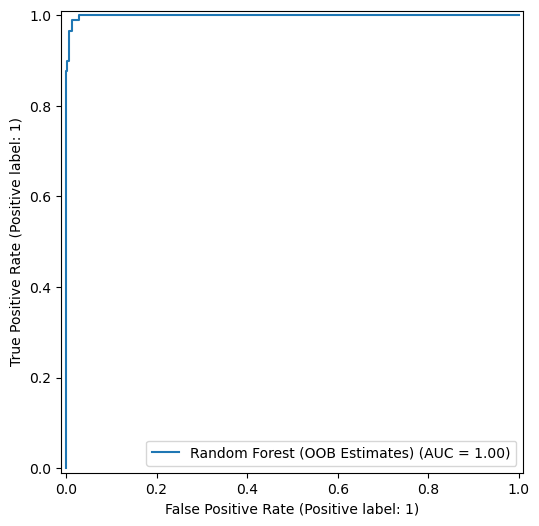

In [100]:
rfClassifier = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      oob_score=True,
                                      random_state=13)

rfClassifier.fit(training_data, training_key.values.ravel()) 

oob_predictions = np.argmax(rfClassifier.oob_decision_function_, axis=1)

oob_probs = rfClassifier.oob_decision_function_[:, 1]  # Get the probabilities for the positive class

# 2. Plot using from_predictions
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    training_key, 
    oob_probs, 
    ax=ax, 
    name="Random Forest (OOB Estimates)"
)

#### 3-fold ROC
I got a little confused with this part, so I ased Gemini to help generate the code snippet for the curve. 

/opt/homebrew/Caskroom/miniforge/base/envs/random/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/random/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/random/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


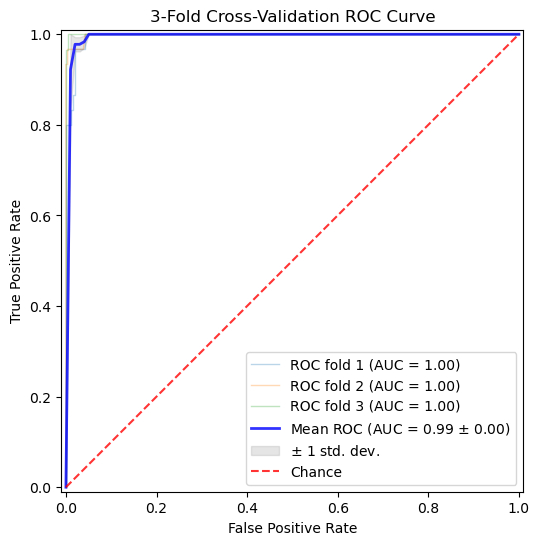

In [95]:
fig, ax = plt.subplots(figsize=(8, 6))

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for i, (train_index, test_index) in enumerate(skf.split(training_data, training_key)):
    # 1. Split and fit
    X_train, X_test = training_data.iloc[train_index], training_data.iloc[test_index]
    y_train, y_test = training_key.iloc[train_index], training_key.iloc[test_index]
    rfClassifier.fit(X_train, y_train.values.ravel())

    # 2. Plot the individual fold curve
    viz = RocCurveDisplay.from_estimator(
        rfClassifier, X_test, y_test, 
        name=f"ROC fold {i+1}", alpha=0.3, lw=1, ax=ax
    )
    
    # 3. Interpolate the TPR for averaging later
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# 4. Calculate and plot the MEAN ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(
    mean_fpr, mean_tpr, color="b",
    label=f"Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})",
    lw=2, alpha=0.8
)

# 5. Add the Standard Deviation Shaded Area
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr, tprs_lower, tprs_upper, color="grey", alpha=0.2,
    label="$\pm$ 1 std. dev."
)

ax.plot([0, 1], [0, 1], linestyle="--", color="r", label="Chance", alpha=0.8)
ax.set(title="3-Fold Cross-Validation ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(loc="lower right")
plt.show()

## Feature ranking
Changing the model name to rfFinal to indicate that is the final RF model with the best score that will be used for feature ranking and prediction. 

In [113]:
feature_names = training_data.columns

rfFinal = RandomForestClassifier(n_estimators=1000, 
                                      max_features=50,
                                      random_state=13)

rfFinal.fit(training_data, training_key.values.ravel()) 

importances = rfFinal.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
print(feature_imp_df.head(10))

      Feature  Gini Importance
235  COL5A2.1         0.090819
239  COL5A2.2         0.077989
165    COL5A2         0.075712
344    NDNF.2         0.033229
244      NDNF         0.032057
312    NDNF.1         0.031091
248      NPNT         0.028796
150      FAT1         0.025734
121       SST         0.025505
164      TOX3         0.024774


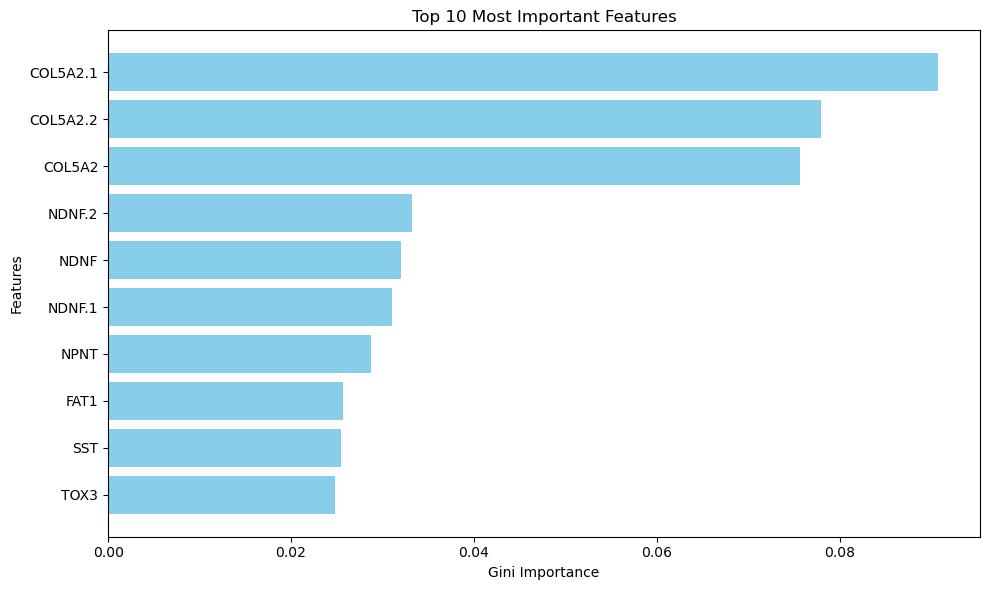

In [105]:
# Plotting the top 10 most important features Code snippet generated from Gemini
top_features = feature_imp_df.head(10)
top_features = top_features.sort_values('Gini Importance', ascending=True)  # Sort for better visualization
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Gini Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features')

# Ensure labels are readable and not truncated
plt.tight_layout()
plt.show()

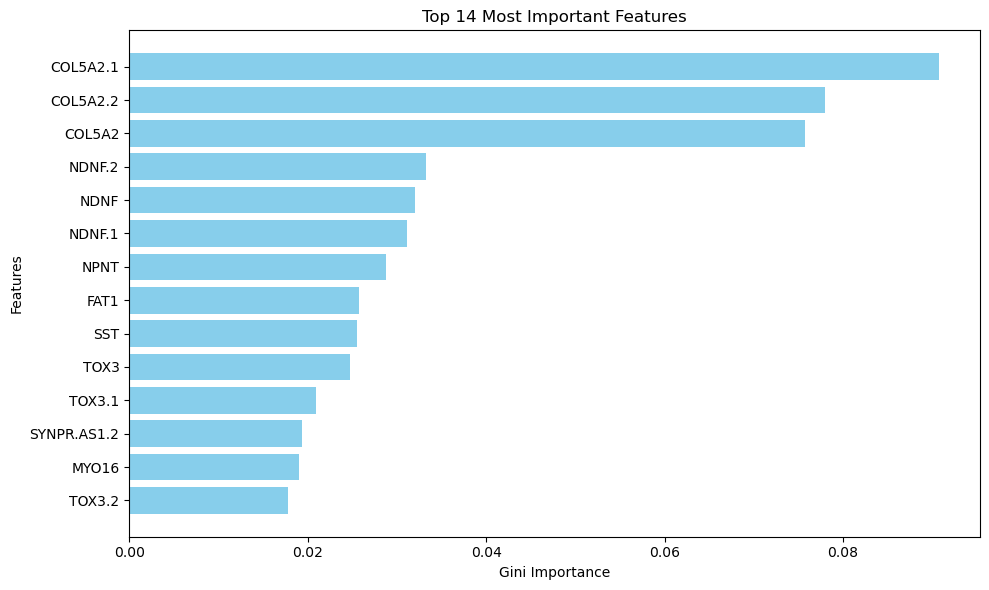

In [114]:
# Plotting the top 10 most important features Code snippet generated from Gemini
top_features = feature_imp_df.head(14)
top_features = top_features.sort_values('Gini Importance', ascending=True)  # Sort for better visualization
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Gini Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('Top 14 Most Important Features')

# Ensure labels are readable and not truncated
plt.tight_layout()
plt.show()

In [117]:
verification_preictions = rfFinal.predict(validation_data)
print("Predicted labels for the validation data:", verification_preictions)
confusion_matrix_result = confusion_matrix(validation_key.values.ravel(), verification_preictions)
print(f"Validation Confusion Matrix: \n{confusion_matrix_result}\n")

probabilities_for_all_classes = rfFinal.predict_proba(validation_data)
print(f"Predicted probabilities for the validation data:\n{probabilities_for_all_classes}")

probabilities_for_class_1 = probabilities_for_all_classes[:, 1]
print("Predicted probabilities for class 1 (positive class):\n", probabilities_for_class_1)

probabilities_for_class_0 = probabilities_for_all_classes[:, 0]
print("Predicted probabilities for class 0 (negative class):\n", probabilities_for_class_0)

Predicted labels for the validation data: [0 1]
Validation Confusion Matrix: 
[[1 0]
 [0 1]]

Predicted probabilities for the validation data:
[[0.994 0.006]
 [0.262 0.738]]
Predicted probabilities for class 1 (positive class):
 [0.006 0.738]
Predicted probabilities for class 0 (negative class):
 [0.994 0.262]


In [122]:
print("Class 0 Prob | Class 1 Prob")
for prob in probabilities_for_all_classes[:5]:
    print(f"{prob[0]:.5f}      | {prob[1]:.5f}")

Class 0 Prob | Class 1 Prob
0.99400      | 0.00600
0.26200      | 0.73800
